In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import copy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

np.random.seed(1983)
torch.manual_seed(1983)

"""## Configuración de recursos"""

device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Usando como dispositivo: {device}")



Usando como dispositivo: cpu


In [2]:
users_df        = pd.read_csv("Final_Updated_Expanded_Users.csv")
history_df      = pd.read_csv("Final_Updated_Expanded_UserHistory.csv")
destinations_df = pd.read_csv("Expanded_Destinations.csv")
reviews_df      = pd.read_csv("Final_Updated_Expanded_Reviews.csv")

print("Usuarios:    ", users_df.shape)
print("Historial:   ", history_df.shape)
print("Destinos:    ", destinations_df.shape)
print("Reviews:     ", reviews_df.shape)

Usuarios:     (999, 7)
Historial:    (999, 5)
Destinos:     (1000, 6)
Reviews:      (999, 5)


## Mapa de preferencia → tipo de destino

Lo necesitamos para el componente de contenido y para las verificaciones.


In [3]:
pref_a_tipo = {"Beaches": "Beach", "Historical": "Historical",
               "Nature": "Nature", "Adventure": "Adventure", "City": "City"}

# TRANSFORMACIÓN 1 — Consolidación de destinos por nombre

Comprobamos primero la firma sintética: 1000 IDs, 5 nombres, 200 IDs por nombre.
Luego construimos un mapa `DestinationID -> ID canónico` (el menor ID del grupo con el mismo `Name`) y lo aplicamos al historial y a las reviews ANTES de codificar.


In [4]:
print("Nombres de destino distintos:", destinations_df["Name"].nunique(), "de", len(destinations_df))
print(destinations_df["Name"].value_counts())

# ID canónico por Name = el menor DestinationID dentro de cada grupo de nombre.
canon_por_nombre = (destinations_df.groupby("Name")["DestinationID"].min().to_dict())
destid_a_canon = {row.DestinationID: canon_por_nombre[row.Name]
                  for row in destinations_df.itertuples(index=False)}

# Tabla de destinos consolidada: 5 filas, Popularity promediada por Name.
dest_consol = (destinations_df
               .groupby("Name")
               .agg(DestinationID=("DestinationID", "min"),
                    State=("State", "first"),
                    Type=("Type", "first"),
                    Popularity=("Popularity", "mean"),
                    BestTimeToVisit=("BestTimeToVisit", "first"))
               .reset_index())
dest_consol = dest_consol[["DestinationID", "Name", "State", "Type",
                           "Popularity", "BestTimeToVisit"]]
print("\nDestinos tras consolidar (Popularity promediada por Name):")
print(dest_consol.to_string(index=False))

# Aplicamos el mapa de consolidación al historial y a las reviews.
history_df["DestCanon"] = history_df["DestinationID"].map(destid_a_canon)
reviews_df["DestCanon"] = reviews_df["DestinationID"].map(destid_a_canon)

print("\nDestinos canónicos distintos en el historial:", history_df["DestCanon"].nunique())

Nombres de destino distintos: 5 de 1000
Name
Taj Mahal            200
Goa Beaches          200
Jaipur City          200
Kerala Backwaters    200
Leh Ladakh           200
Name: count, dtype: int64

Destinos tras consolidar (Popularity promediada por Name):
 DestinationID              Name             State       Type  Popularity BestTimeToVisit
             2       Goa Beaches               Goa      Beach    8.495206         Nov-Mar
             3       Jaipur City         Rajasthan       City    8.530317         Oct-Mar
             4 Kerala Backwaters            Kerala     Nature    8.490535         Sep-Mar
             5        Leh Ladakh Jammu and Kashmir  Adventure    8.504099         Apr-Jun
             1         Taj Mahal     Uttar Pradesh Historical    8.549476         Nov-Feb

Destinos canónicos distintos en el historial: 5


# TRANSFORMACIÓN 2 — Identidad de usuario por correo

Las 999 filas de usuario son 20 personas (20 correos únicos). Construimos un mapa `UserID -> persona canónica` (el menor `UserID` que comparte el mismo `Email`) y lo aplicamos al historial y a las reviews.


In [5]:
print("Correos únicos:", users_df["Email"].nunique(), "de", len(users_df))

# Persona canónica = menor UserID por correo.
canon_por_email = users_df.groupby("Email")["UserID"].min().to_dict()
userid_a_email  = users_df.set_index("UserID")["Email"].to_dict()
userid_a_canon  = {uid: canon_por_email[email] for uid, email in userid_a_email.items()}

history_df["UserCanon"] = history_df["UserID"].map(userid_a_canon)
reviews_df["UserCanon"] = reviews_df["UserID"].map(userid_a_canon)

print("Personas canónicas distintas en el historial:", history_df["UserCanon"].nunique())

# Interacciones por persona tras consolidar.
ix_pp = history_df.groupby("UserCanon").size()
print("\nInteracciones por persona (estadísticos):")
print(ix_pp.describe())


Correos únicos: 20 de 999
Personas canónicas distintas en el historial: 20

Interacciones por persona (estadísticos):
count    20.000000
mean     49.950000
std       8.127115
min      31.000000
25%      47.000000
50%      49.500000
75%      52.500000
max      73.000000
dtype: float64


## Política de preferencia por persona (decisión explícita)

Cada persona aparece con varias filas y, sumadas, sus combinaciones cubren **los 5 tipos**. Verifiquémoslo: si acumuláramos todas las preferencias en un multi-hot, el vector sería *todo-unos* para todas las personas, es decir, una feature **degenerada** (constante) y por tanto inútil.

Por eso elegimos una política distinta: usar **la combinación de preferencia más
frecuente de cada persona** y convertirla en multi-hot (2 tipos en 1). Esto sí produce variación entre personas. Aun así, es una variación esencialmente aleatoria: como ya demostramos, la preferencia no predice el comportamiento. La elegimos porque es la única que no degenera a una constante, no porque esperemos que aporte señal.

In [6]:
def tokens_persona(serie):
    out = set()
    for x in serie:
        for t in str(x).split(","):
            t = t.strip()
            if t:
                out.add(t)
    return out

# Verificación de la degeneración del multi-hot acumulado.
tokens_acumulados = users_df.groupby("Email")["Preferences"].agg(tokens_persona)
todos_iguales = all(v == set(pref_a_tipo.keys()) for v in tokens_acumulados)
print("¿El multi-hot acumulado da TODOS los tipos para TODAS las personas?", todos_iguales)
print("=> Por eso NO usamos el multi-hot acumulado (sería una feature constante).")

# Política elegida: combinación más frecuente por persona.
def combo_mas_frecuente(serie):
    return serie.value_counts().idxmax()

combo_por_email = users_df.groupby("Email")["Preferences"].agg(combo_mas_frecuente)
print("\nCombinación de preferencia más frecuente por persona:")
print(combo_por_email.to_string())

# Multi-hot (5 tipos) a partir del combo más frecuente.
tipos_orden = ["Beaches", "Historical", "Nature", "Adventure", "City"]
def combo_a_multihot(combo):
    presentes = {t.strip() for t in combo.split(",")}
    return [1 if t in presentes else 0 for t in tipos_orden]

# Tabla de persona canónica -> features de preferencia + demografía.
personas = (users_df.sort_values("UserID")
            .drop_duplicates(subset="Email", keep="first")
            .copy())
personas["Canon"] = personas["Email"].map(canon_por_email)
personas["ComboFreq"] = personas["Email"].map(combo_por_email)
pref_cols = ["pref_" + t for t in tipos_orden]
personas[pref_cols] = personas["ComboFreq"].apply(
    lambda c: pd.Series(combo_a_multihot(c)))

gender_encoder = LabelEncoder()
personas["GenderEnc"] = gender_encoder.fit_transform(personas["Gender"].fillna("Unknown"))

# Demografía: tomamos la de la fila canónica (menor UserID) de cada persona.
feat_cols = pref_cols + ["GenderEnc", "NumberOfAdults", "NumberOfChildren"]
n_user_features = len(feat_cols)
features_persona = personas.set_index("Canon")[feat_cols]
print("\nColumnas de features de usuario:", feat_cols)



¿El multi-hot acumulado da TODOS los tipos para TODAS las personas? True
=> Por eso NO usamos el multi-hot acumulado (sería una feature constante).

Combinación de preferencia más frecuente por persona:
Email
aanya@example.com     Beaches, Historical
aarav@example.com        City, Historical
aditya@example.com       City, Historical
anika@example.com     Beaches, Historical
arjun@example.com       Nature, Adventure
dhruv@example.com        City, Historical
diya@example.com        Nature, Adventure
hitesh@example.com       City, Historical
isha@example.com         City, Historical
ishaan@example.com      Nature, Adventure
karan@example.com       Nature, Adventure
kavya@example.com       Nature, Adventure
meera@example.com       Nature, Adventure
pooja@example.com     Beaches, Historical
ritvik@example.com    Beaches, Historical
riya@example.com         City, Historical
rohan@example.com       Nature, Adventure
saanvi@example.com    Beaches, Historical
tanvi@example.com        City, Hist

# TRANSFORMACIÓN 3 — Integración de reviews y mes de visita

### 3a. Combinar `ExperienceRating` (historial) con `Rating` (reviews)

Para cada par (persona canónica, destino canónico) puede haber un rating del historial, uno de reviews, ambos o ninguno. **Política de combinación:** si existen ambos, usamos el **promedio**; si solo existe uno, usamos ese.

In [7]:
# Rating del historial por (UserCanon, DestCanon): promedio si hay varias filas.
hist_rating = (history_df
               .groupby(["UserCanon", "DestCanon"])["ExperienceRating"]
               .mean()
               .rename("rating_hist")
               .reset_index())

# Rating de reviews por (UserCanon, DestCanon): promedio si hay varias.
rev_rating = (reviews_df
              .groupby(["UserCanon", "DestCanon"])["Rating"]
              .mean()
              .rename("rating_rev")
              .reset_index())

# Mes de visita "representativo" por par: el mes más frecuente del historial.
history_df["Mes"] = pd.to_datetime(history_df["VisitDate"]).dt.month
mes_par = (history_df
           .groupby(["UserCanon", "DestCanon"])["Mes"]
           .agg(lambda s: s.value_counts().idxmax())
           .rename("Mes")
           .reset_index())

# Unimos las dos fuentes de rating por unión externa.
inter = pd.merge(hist_rating, rev_rating, on=["UserCanon", "DestCanon"], how="outer")

# Combinación: promedio de las fuentes disponibles (nanmean fila a fila).
inter["Rating"] = inter[["rating_hist", "rating_rev"]].mean(axis=1, skipna=True)

# Adjuntamos el mes (de existir); si el par solo viene de reviews, no hay mes -> imputamos.
inter = inter.merge(mes_par, on=["UserCanon", "DestCanon"], how="left")

print("Pares (persona, destino) con ambos ratings:",
      inter[["rating_hist", "rating_rev"]].notna().all(axis=1).sum())
print("Pares solo con historial:", inter["rating_hist"].notna().sum()
      - inter[["rating_hist", "rating_rev"]].notna().all(axis=1).sum())
print("Pares solo con reviews:", inter["rating_rev"].notna().sum()
      - inter[["rating_hist", "rating_rev"]].notna().all(axis=1).sum())
print("Total de interacciones consolidadas:", len(inter))

Pares (persona, destino) con ambos ratings: 100
Pares solo con historial: 0
Pares solo con reviews: 0
Total de interacciones consolidadas: 100


### 3b. Codificación cíclica del mes

El mes es una variable circular (diciembre está cerca de enero), así que en vez de un entero 1-12 usamos la codificación seno/coseno habitual:
`mes_sin = sin(2π·mes/12)`, `mes_cos = cos(2π·mes/12)`. Imputamos el mes faltante con la moda global antes de transformar.

In [8]:
mes_moda = int(history_df["Mes"].mode().iloc[0])
inter["Mes"] = inter["Mes"].fillna(mes_moda).astype(int)
inter["mes_sin"] = np.sin(2 * np.pi * inter["Mes"] / 12.0)
inter["mes_cos"] = np.cos(2 * np.pi * inter["Mes"] / 12.0)

# Renombramos para el resto del pipeline.
inter = inter.rename(columns={"UserCanon": "UserID", "DestCanon": "DestinationID"})
inter = inter.dropna(subset=["Rating"]).reset_index(drop=True)

## Verificación de señal tras consolidar (igual que en el proyecto principal)

Antes de modelar, repetimos la prueba de coincidencia preferencia-tipo y la relación rating-popularidad, ahora sobre los datos consolidados. Si las transformaciones hubieran "revelado" señal, deberíamos verlo aquí.

In [9]:
inter = inter.merge(dest_consol[["DestinationID", "Type", "Popularity"]],
                    on="DestinationID", how="left")
inter = inter.merge(combo_por_email.rename("ComboFreq"),
                    left_on=inter["UserID"].map(canon_email_inv := {v: k for k, v in canon_por_email.items()}),
                    right_index=True, how="left")

def coincide(fila):
    tipos = {pref_a_tipo.get(t.strip()) for t in str(fila["ComboFreq"]).split(",")}
    return 1 if fila["Type"] in tipos else 0

inter["coincide"] = inter.apply(coincide, axis=1)
print("Tasa de coincidencia preferencia(frecuente)-tipo:", round(inter["coincide"].mean(), 4))
print("(Con 2 tipos preferidos sobre 5, el azar daría ~0.40)")
print("\nRating promedio según coincidencia con la preferencia:")
print(inter.groupby("coincide")["Rating"].agg(["mean", "count"]))
print("\nCorrelación Popularidad vs Rating (consolidado):",
      round(inter["Popularity"].corr(inter["Rating"]), 4))
print("=> Como en el proyecto principal, la señal sigue ausente tras consolidar.")



Tasa de coincidencia preferencia(frecuente)-tipo: 0.4
(Con 2 tipos preferidos sobre 5, el azar daría ~0.40)

Rating promedio según coincidencia con la preferencia:
              mean  count
coincide                 
0         2.996200     60
1         2.945865     40

Correlación Popularidad vs Rating (consolidado): 0.0403
=> Como en el proyecto principal, la señal sigue ausente tras consolidar.


# Codificación de IDs a índices contiguos

Los embeddings de PyTorch requieren índices 0..N-1. Codificamos las personas y los destinos canónicos.

In [10]:
user_encoder = LabelEncoder()
dest_encoder = LabelEncoder()
inter["u"] = user_encoder.fit_transform(inter["UserID"])
inter["i"] = dest_encoder.fit_transform(inter["DestinationID"])

n_users = inter["u"].nunique()
n_items = inter["i"].nunique()
print(f"n_users = {n_users}  (antes ~642)")
print(f"n_items = {n_items}  (antes ~638)")

# Adjuntamos las features de usuario a cada interacción.
feat_lookup = features_persona.reindex(user_encoder.classes_).fillna(0)
feat_matrix = feat_lookup.values.astype(np.float32)  # filas alineadas a 'u'
mes_feats = inter[["mes_sin", "mes_cos"]].values.astype(np.float32)

# El vector de features finales = [features de persona] + [mes_sin, mes_cos]
X_user = feat_matrix[inter["u"].values]
X_full = np.concatenate([X_user, mes_feats], axis=1).astype(np.float32)
n_user_features = X_full.shape[1]
feat_cols_full = feat_cols + ["mes_sin", "mes_cos"]
print("Features por interacción:", feat_cols_full, "->", n_user_features, "dims")

inter_feats = pd.DataFrame(X_full, columns=feat_cols_full)
data = pd.concat([inter[["u", "i", "Rating"]].reset_index(drop=True), inter_feats], axis=1)

n_users = 20  (antes ~642)
n_items = 5  (antes ~638)
Features por interacción: ['pref_Beaches', 'pref_Historical', 'pref_Nature', 'pref_Adventure', 'pref_City', 'GenderEnc', 'NumberOfAdults', 'NumberOfChildren', 'mes_sin', 'mes_cos'] -> 10 dims


# Split entrenamiento / validación con Leave-One-Out

Mismo procedimiento del proyecto principal: escondemos UNA interacción por persona (de las que tienen 2 o más) como test; el resto va a entrenamiento.

In [11]:
def split_leave_one_out(df, seed=1983):
    rng = np.random.default_rng(seed)
    test_idx = []
    for u, grupo in df.groupby("u"):
        idxs = grupo.index.to_numpy()
        if len(idxs) >= 2:
            test_idx.append(rng.choice(idxs))
    test_idx = np.array(test_idx)
    train = df.drop(index=test_idx).reset_index(drop=True)
    test = df.loc[test_idx].reset_index(drop=True)
    return train, test

train_df, test_df = split_leave_one_out(data)
print(f"Entrenamiento: {len(train_df)}  |  Test (1 por persona multi-visita): {len(test_df)}")

global_mean = train_df["Rating"].mean()
print(f"Rating medio (train): {global_mean:.3f}")


Entrenamiento: 80  |  Test (1 por persona multi-visita): 20
Rating medio (train): 2.975


# Baseline honesto: media global

Sigue siendo la referencia central. Si el modelo neuronal no baja claramente de este RMSE, no aprendió nada útil.

[Regresión] Media global -> RMSE=0.3295  MAE=0.2579
=== Entrenando NCF híbrido (datos consolidados) ===
El NCF tiene 5777 parámetros entrenables
Epoch  10 | RMSE train=1.2325 | RMSE val=0.4892
Epoch  20 | RMSE train=1.3154 | RMSE val=0.9803
Epoch  30 | RMSE train=1.1834 | RMSE val=0.5547
Early stopping en epoch 31.
Mejor RMSE val = 0.4468 (epoch 16)

=== Entrenando Factorización de Matrices (datos consolidados) ===
Epoch  10 | RMSE train=2.6737 | RMSE val=3.1028
Epoch  20 | RMSE train=2.3699 | RMSE val=2.9327
Epoch  30 | RMSE train=2.1017 | RMSE val=2.7804
Epoch  40 | RMSE train=1.8669 | RMSE val=2.6490
Epoch  50 | RMSE train=1.6624 | RMSE val=2.5366
Epoch  60 | RMSE train=1.4841 | RMSE val=2.4407
Epoch  70 | RMSE train=1.3286 | RMSE val=2.3593
Epoch  80 | RMSE train=1.1926 | RMSE val=2.2904
Epoch  90 | RMSE train=1.0736 | RMSE val=2.2324
Epoch 100 | RMSE train=0.9692 | RMSE val=2.1838
Epoch 110 | RMSE train=0.8774 | RMSE val=2.1433
Epoch 120 | RMSE train=0.7964 | RMSE val=2.1095
Epoch

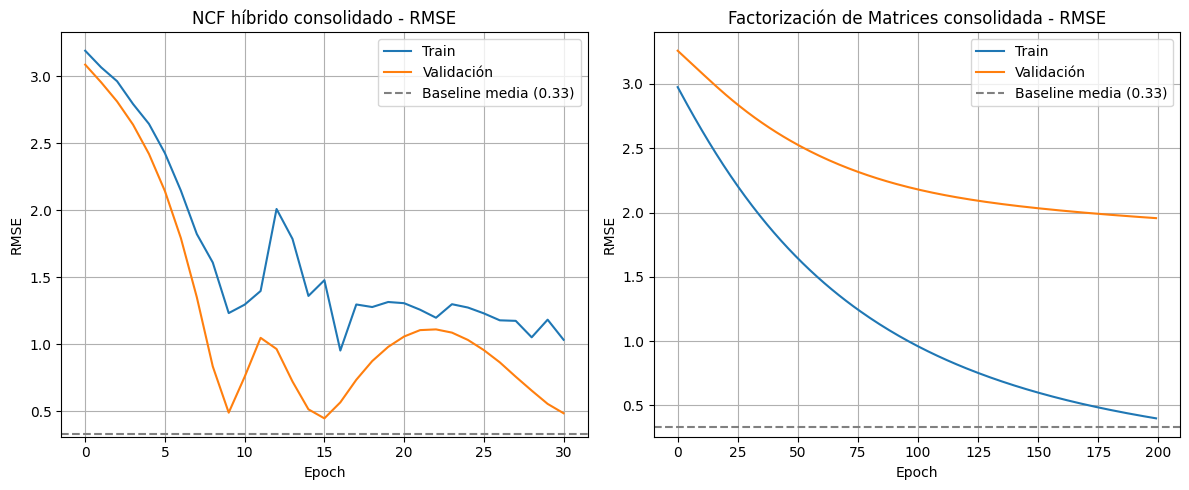

In [12]:

y_test = test_df["Rating"].values
pred_media = np.full_like(y_test, global_mean, dtype=float)
rmse_media = np.sqrt(mean_squared_error(y_test, pred_media))
mae_media = mean_absolute_error(y_test, pred_media)
print(f"[Regresión] Media global -> RMSE={rmse_media:.4f}  MAE={mae_media:.4f}")

class TravelDataset(Dataset):
    def __init__(self, df, feat_cols):
        self.u = torch.tensor(df["u"].values, dtype=torch.long)
        self.i = torch.tensor(df["i"].values, dtype=torch.long)
        self.f = torch.tensor(df[feat_cols].values, dtype=torch.float32)
        self.r = torch.tensor(df["Rating"].values, dtype=torch.float32)

    def __len__(self):
        return len(self.u)

    def __getitem__(self, idx):
        return self.u[idx], self.i[idx], self.f[idx], self.r[idx]

batch_size = 128
train_loader = DataLoader(TravelDataset(train_df, feat_cols_full),
                          batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TravelDataset(test_df, feat_cols_full),
                         batch_size=256, shuffle=False)

class HybridNCF(nn.Module):
    def __init__(self, n_users, n_items, embedding_dim, n_user_features,
                 layers, dropout=0.3):
        super(HybridNCF, self).__init__()
        self.user_embedding = nn.Embedding(n_users, embedding_dim)
        self.item_embedding = nn.Embedding(n_items, embedding_dim)

        capa_entrada = embedding_dim * 2 + n_user_features
        dims = [capa_entrada] + layers

        self.fc_layers = nn.ModuleList()
        for k in range(len(dims) - 1):
            self.fc_layers.append(nn.Linear(dims[k], dims[k + 1]))

        self.output_layer = nn.Linear(dims[-1], 1)
        self.activation = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, user_input, item_input, user_features):
        u = self.user_embedding(user_input)
        i = self.item_embedding(item_input)
        x = torch.cat([u, i, user_features], dim=-1)
        for layer in self.fc_layers:
            x = self.dropout(self.activation(layer(x)))
        return self.output_layer(x).squeeze()

class MatrixFactorization(nn.Module):
    def __init__(self, n_users, n_items, n_factors, global_mean):
        super(MatrixFactorization, self).__init__()
        self.user_factors = nn.Embedding(n_users, n_factors)
        self.item_factors = nn.Embedding(n_items, n_factors)
        self.user_bias = nn.Embedding(n_users, 1)
        self.item_bias = nn.Embedding(n_items, 1)
        self.global_bias = nn.Parameter(torch.tensor(float(global_mean)))

    def forward(self, user, item, user_features=None):
        dot = (self.user_factors(user) * self.item_factors(item)).sum(dim=1)
        return dot + self.user_bias(user).squeeze() + \
               self.item_bias(item).squeeze() + self.global_bias

def rmse_en_loader(model, loader):
    model.eval()
    se, n = 0.0, 0
    with torch.no_grad():
        for u, i, f, r in loader:
            p = model(u.to(device), i.to(device), f.to(device)).cpu()
            se += ((p - r) ** 2).sum().item()
            n += len(r)
    return (se / n) ** 0.5

def entrenar(model, train_loader, val_loader, lr=0.005, weight_decay=1e-4,
             epochs=200, patience=15):
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    hist_train, hist_val = [], []
    best_val = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    best_epoch, sin_mejora = 0, 0

    for epoch in range(epochs):
        model.train()
        total = 0.0
        for u, i, f, r in train_loader:
            optimizer.zero_grad()
            pred = model(u.to(device), i.to(device), f.to(device))
            loss = criterion(pred, r.to(device))
            loss.backward()
            optimizer.step()
            total += loss.item()

        rmse_tr = (total / len(train_loader)) ** 0.5
        rmse_va = rmse_en_loader(model, val_loader)
        hist_train.append(rmse_tr)
        hist_val.append(rmse_va)

        if rmse_va < best_val - 1e-4:
            best_val = rmse_va
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            sin_mejora = 0
        else:
            sin_mejora += 1

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d} | RMSE train={rmse_tr:.4f} | RMSE val={rmse_va:.4f}")

        if sin_mejora >= patience:
            print(f"Early stopping en epoch {epoch+1}.")
            break

    model.load_state_dict(best_state)
    print(f"Mejor RMSE val = {best_val:.4f} (epoch {best_epoch+1})")
    return model, hist_train, hist_val, best_val

# --- Hiperparámetros IDÉNTICOS al proyecto principal ---
embedding_dim = 16
layers = [64, 32, 16]
n_factors = 8

print("=== Entrenando NCF híbrido (datos consolidados) ===")
ncf = HybridNCF(n_users, n_items, embedding_dim, n_user_features,
                layers, dropout=0.3).to(device)
num_par = sum(p.numel() for p in ncf.parameters() if p.requires_grad)
print(f"El NCF tiene {num_par} parámetros entrenables")
ncf, h_tr_ncf, h_va_ncf, best_ncf = entrenar(
    ncf, train_loader, test_loader, lr=0.005, weight_decay=1e-4)

print("\n=== Entrenando Factorización de Matrices (datos consolidados) ===")
mf = MatrixFactorization(n_users, n_items, n_factors, global_mean).to(device)
mf, h_tr_mf, h_va_mf, best_mf = entrenar(
    mf, train_loader, test_loader, lr=0.005, weight_decay=1e-3)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(h_tr_ncf, label="Train")
plt.plot(h_va_ncf, label="Validación")
plt.axhline(rmse_media, color="gray", ls="--", label=f"Baseline media ({rmse_media:.2f})")
plt.title("NCF híbrido consolidado - RMSE")
plt.xlabel("Epoch"); plt.ylabel("RMSE"); plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(h_tr_mf, label="Train")
plt.plot(h_va_mf, label="Validación")
plt.axhline(rmse_media, color="gray", ls="--", label=f"Baseline media ({rmse_media:.2f})")
plt.title("Factorización de Matrices consolidada - RMSE")
plt.xlabel("Epoch"); plt.ylabel("RMSE"); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

# Comparación de RMSE: experimental vs baseline vs modelo original

El modelo original (sobre ~638 ítems, sin consolidar) reportó en el proyecto principal un RMSE_val ≈ 1.53. Lo incluimos como referencia fija para comparar.

In [13]:
RMSE_ORIGINAL_638 = 1.53  # valor reportado por el modelo principal (638 ítems)

resumen = pd.DataFrame({
    "Modelo": ["Baseline media global (consolidado)",
               "NCF híbrido (consolidado, 5 ítems)",
               "Factorización matrices (consolidado)",
               "NCF original (referencia, 638 ítems)"],
    "RMSE_val": [rmse_media, best_ncf, best_mf, RMSE_ORIGINAL_638]
})
print(resumen.to_string(index=False))
print("\nLectura: si el NCF consolidado no baja claramente del baseline de media,")
print("la consolidación no recuperó señal (resultado esperado por el análisis previo).")

                              Modelo  RMSE_val
 Baseline media global (consolidado)  0.329465
  NCF híbrido (consolidado, 5 ítems)  0.446775
Factorización matrices (consolidado)  1.956679
NCF original (referencia, 638 ítems)  1.530000

Lectura: si el NCF consolidado no baja claramente del baseline de media,
la consolidación no recuperó señal (resultado esperado por el análisis previo).


# Predicho vs Real (réplica del gráfico de clase)

Con datos sin señal, las predicciones se concentran alrededor de la media y no se alinean con la diagonal.

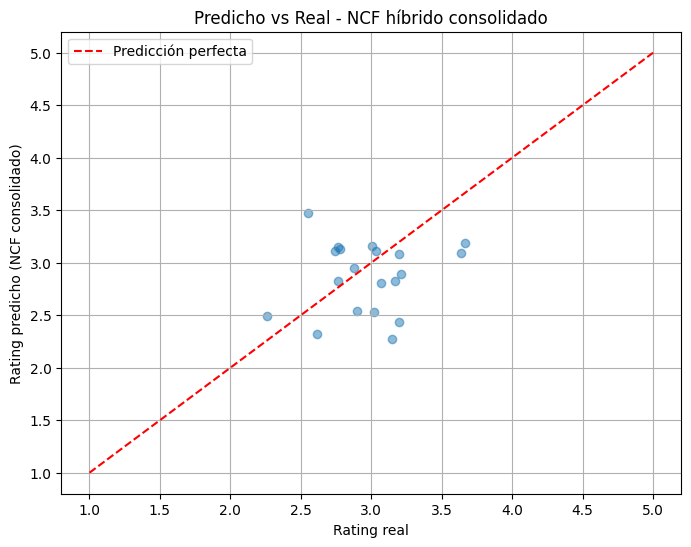

In [14]:
ncf.eval()
reales, predichos = [], []
with torch.no_grad():
    for u, i, f, r in test_loader:
        p = ncf(u.to(device), i.to(device), f.to(device)).cpu().numpy()
        predichos.extend(np.atleast_1d(p))
        reales.extend(r.numpy())
reales = np.array(reales); predichos = np.array(predichos)

plt.figure(figsize=(8, 6))
plt.scatter(reales, predichos, alpha=0.5)
plt.plot([1, 5], [1, 5], "r--", label="Predicción perfecta")
plt.xlabel("Rating real"); plt.ylabel("Rating predicho (NCF consolidado)")
plt.title("Predicho vs Real - NCF híbrido consolidado")
plt.legend(); plt.grid(True); plt.show()

# Ranking tras la consolidación: por qué deja de ser informativo

Esta es una consecuencia metodológica importante (y un punto de análisis, no un
defecto a esconder). Tras consolidar, el catálogo tiene **solo 5 destinos**. En la
evaluación leave-one-out, para cada persona los candidatos no vistos son a lo sumo 4,
de modo que **el Top-5 es prácticamente el catálogo completo**:

- `Recall@5 = 100%` para CUALQUIER modelo, incluido el azar (el ítem correcto siempre
  cae dentro del Top-5 porque hay ≤5 ítems en total).
- `Precision@5` queda fijada por la aritmética (1 acierto / 5), no por la calidad del
  modelo.

Por eso, tras la consolidación, **la evaluación principal pasa a ser el RMSE de
regresión contra el baseline de la media**, no el ranking. Lo ilustramos numéricamente:


In [15]:
K = 5
items_train_por_usuario = train_df.groupby("u")["i"].apply(set).to_dict()
todos_los_items = np.arange(n_items)

# feature por usuario: tomamos la feature de persona (sin el mes) y rellenamos
# el mes con la moda transformada para los candidatos del ranking.
mes_sin_moda = np.sin(2 * np.pi * mes_moda / 12.0)
mes_cos_moda = np.cos(2 * np.pi * mes_moda / 12.0)
feat_persona_por_u = {u: feat_matrix[u] for u in range(n_users)}

def score_ncf(u, candidatos):
    ncf.eval()
    with torch.no_grad():
        base = np.concatenate([feat_persona_por_u[u], [mes_sin_moda, mes_cos_moda]])
        ut = torch.tensor([u] * len(candidatos), dtype=torch.long).to(device)
        it = torch.tensor(candidatos, dtype=torch.long).to(device)
        ft = torch.tensor(np.tile(base, (len(candidatos), 1)), dtype=torch.float32).to(device)
        return np.atleast_1d(ncf(ut, it, ft).cpu().numpy())

def score_azar(u, candidatos):
    return np.random.rand(len(candidatos))

def evaluar_ranking(score_fn, K=5):
    precisiones, recalls = [], []
    for _, fila in test_df.iterrows():
        u, verdadero = int(fila["u"]), int(fila["i"])
        vistos = items_train_por_usuario.get(u, set())
        candidatos = np.array([it for it in todos_los_items if it not in vistos])
        if len(candidatos) == 0:
            continue
        scores = score_fn(u, candidatos)
        orden = np.argsort(-scores)
        topk = candidatos[orden[:K]]
        hit = 1 if verdadero in topk else 0
        precisiones.append(hit / K)
        recalls.append(hit)
    return np.mean(precisiones), np.mean(recalls)

p_ncf, r_ncf = evaluar_ranking(score_ncf, K)
p_rnd, r_rnd = evaluar_ranking(score_azar, K)
ranking = pd.DataFrame({
    "Modelo": ["NCF consolidado", "Azar"],
    f"Precision@{K}": [p_ncf, p_rnd],
    f"Recall@{K}": [r_ncf, r_rnd],
})
print(ranking.to_string(index=False))
print(f"\nNúmero de ítems en el catálogo consolidado: {n_items}")
print("Como se anticipó, Recall@5 ≈ 1.0 para todos (el Top-5 es casi todo el catálogo).")
print("=> La métrica de ranking deja de ser informativa; usamos el RMSE como evaluación principal.")



         Modelo  Precision@5  Recall@5
NCF consolidado          0.2       1.0
           Azar          0.2       1.0

Número de ítems en el catálogo consolidado: 5
Como se anticipó, Recall@5 ≈ 1.0 para todos (el Top-5 es casi todo el catálogo).
=> La métrica de ranking deja de ser informativa; usamos el RMSE como evaluación principal.


# Matriz de confusión (recomendar / no recomendar)

Convertimos a binario: rating ≥ 4 = "recomendable". Es la misma lectura del proyecto principal; aquí la incluimos por completitud.

Accuracy : 1.0
Precision: 0.0
Recall   : 0.0
F1-Score : 0.0

               precision    recall  f1-score   support

           0       1.00      1.00      1.00        20

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



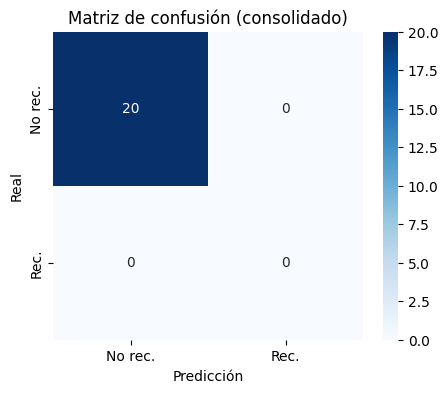

In [16]:
umbral = 4
real_bin = (reales >= umbral).astype(int)
pred_bin = (predichos >= umbral).astype(int)

print("Accuracy :", round(accuracy_score(real_bin, pred_bin), 4))
print("Precision:", round(precision_score(real_bin, pred_bin, zero_division=0), 4))
print("Recall   :", round(recall_score(real_bin, pred_bin, zero_division=0), 4))
print("F1-Score :", round(f1_score(real_bin, pred_bin, zero_division=0), 4))
print("\n", classification_report(real_bin, pred_bin, zero_division=0))

cm = confusion_matrix(real_bin, pred_bin, labels=[0, 1])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No rec.", "Rec."], yticklabels=["No rec.", "Rec."])
plt.xlabel("Predicción"); plt.ylabel("Real")
plt.title("Matriz de confusión (consolidado)")
plt.show()

# Análisis de embeddings de destinos (5 puntos)

### ADVERTENCIA de interpretación

Con solo **5 destinos**, el PCA proyecta exactamente **5 puntos**. Cinco puntos en un plano *siempre* se ven separados entre sí: eso es **geometría**, no aprendizaje. La matriz de similitud 5x5 que calculamos abajo es **ilustrativa**, pero sus valores son **espurios**: como los ratings son aleatorios, los embeddings no codifican afinidades reales entre tipos de destino. No debe sobreinterpretarse.

Tamaño de la matriz de embeddings de destinos: (5, 16)


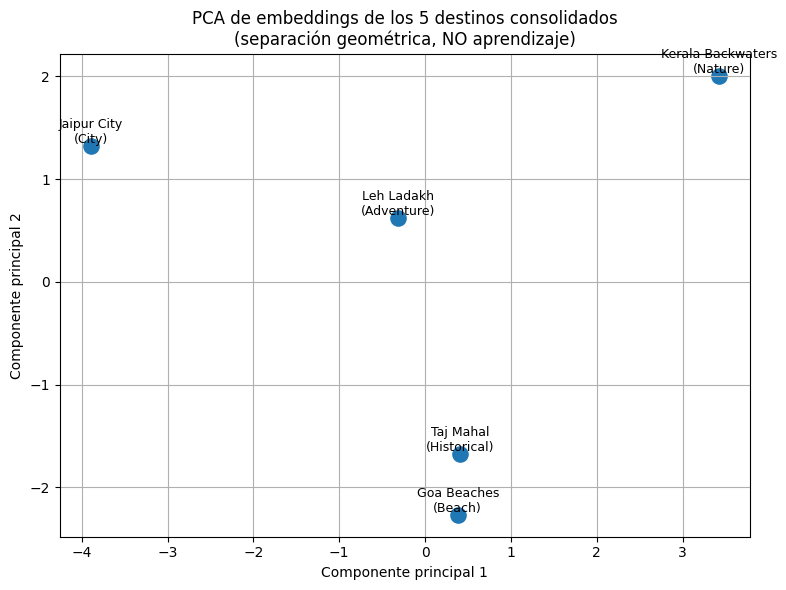

Similitud coseno entre los 5 destinos (recordatorio: valores espurios):
                            Taj Mahal (Historical)  Goa Beaches (Beach)  \
Taj Mahal (Historical)                       1.000                0.582   
Goa Beaches (Beach)                          0.582                1.000   
Jaipur City (City)                           0.027               -0.023   
Kerala Backwaters (Nature)                   0.232                0.159   
Leh Ladakh (Adventure)                       0.465                0.124   

                            Jaipur City (City)  Kerala Backwaters (Nature)  \
Taj Mahal (Historical)                   0.027                       0.232   
Goa Beaches (Beach)                     -0.023                       0.159   
Jaipur City (City)                       1.000                      -0.365   
Kerala Backwaters (Nature)              -0.365                       1.000   
Leh Ladakh (Adventure)                   0.192                       0.201   

        

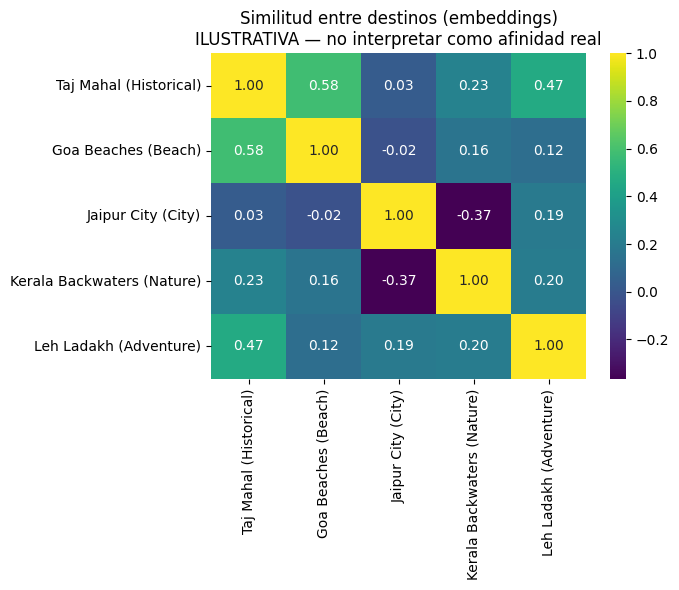

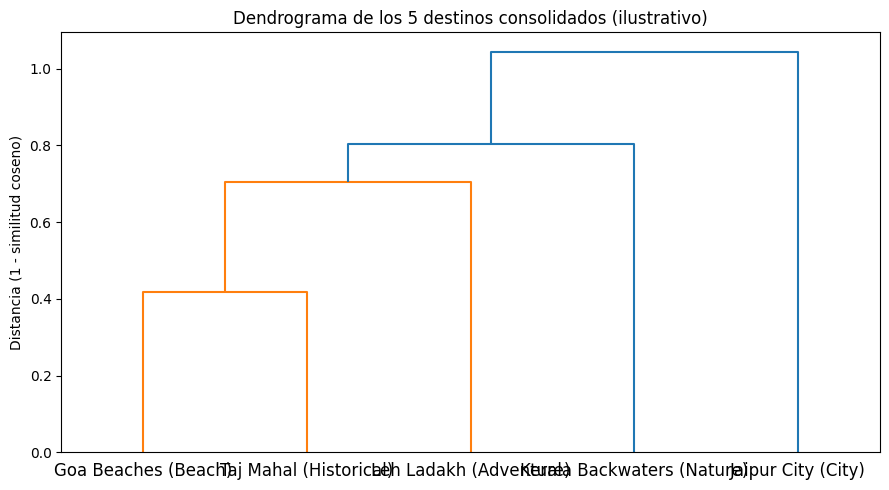

              Metrica     Valor
  RMSE_baseline_media  0.329465
 RMSE_NCF_consolidado  0.446775
  RMSE_MF_consolidado  1.956679
RMSE_NCF_original_638  1.530000
  n_users_consolidado 20.000000
  n_items_consolidado  5.000000
      Precision@5_NCF  0.200000
         Recall@5_NCF  1.000000
         Accuracy_bin  1.000000
               F1_bin  0.000000

Modelo y métricas del experimento guardados.


In [17]:
emb_items = ncf.item_embedding.weight.data.cpu().numpy()
print("Tamaño de la matriz de embeddings de destinos:", emb_items.shape)

# Mapa índice de ítem -> Nombre / Tipo del destino canónico.
idx_a_destid = {idx: did for idx, did in
                zip(dest_encoder.transform(dest_encoder.classes_), dest_encoder.classes_)}
destid_a_nombre = dest_consol.set_index("DestinationID")["Name"].to_dict()
destid_a_tipo = dest_consol.set_index("DestinationID")["Type"].to_dict()
nombres_items = [destid_a_nombre[idx_a_destid[k]] for k in range(n_items)]
tipos_items = [destid_a_tipo[idx_a_destid[k]] for k in range(n_items)]

# PCA con tantos componentes como permita (min(5, dim) ); usamos 2 para graficar.
n_comp = min(2, n_items, emb_items.shape[1])
pca = PCA(n_components=n_comp)
emb_pca = pca.fit_transform(emb_items)

plt.figure(figsize=(8, 6))
plt.scatter(emb_pca[:, 0], emb_pca[:, 1] if n_comp > 1 else np.zeros(n_items),
            s=120)
for k in range(n_items):
    plt.annotate(f"{nombres_items[k]}\n({tipos_items[k]})",
                 (emb_pca[k, 0], emb_pca[k, 1] if n_comp > 1 else 0),
                 fontsize=9, ha="center", va="bottom")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2" if n_comp > 1 else "")
plt.title("PCA de embeddings de los 5 destinos consolidados\n(separación geométrica, NO aprendizaje)")
plt.grid(True); plt.tight_layout(); plt.show()

"""## Similitud coseno 5x5 (ilustrativa, valores espurios)"""

sim = cosine_similarity(emb_items)
etiquetas = [f"{nombres_items[k]} ({tipos_items[k]})" for k in range(n_items)]
sim_df = pd.DataFrame(sim, index=etiquetas, columns=etiquetas)
print("Similitud coseno entre los 5 destinos (recordatorio: valores espurios):")
print(sim_df.round(3))

plt.figure(figsize=(7, 6))
sns.heatmap(sim_df, annot=True, cmap="viridis", fmt=".2f")
plt.title("Similitud entre destinos (embeddings)\nILUSTRATIVA — no interpretar como afinidad real")
plt.tight_layout(); plt.show()

"""## Clustering jerárquico de los 5 destinos (ilustrativo)"""

dist = 1 - sim
np.fill_diagonal(dist, 0)
dist = (dist + dist.T) / 2  # asegurar simetría numérica
condensada = squareform(dist, checks=False)
enlace = linkage(condensada, method="average")

plt.figure(figsize=(9, 5))
dendrogram(enlace, labels=etiquetas, distance_sort="descending")
plt.title("Dendrograma de los 5 destinos consolidados (ilustrativo)")
plt.ylabel("Distancia (1 - similitud coseno)")
plt.tight_layout(); plt.show()

"""# Guardado de métricas del experimento"""

torch.save(ncf.state_dict(), "ncf_consolidado_destinos.pth")

metricas = pd.DataFrame({
    "Metrica": ["RMSE_baseline_media", "RMSE_NCF_consolidado", "RMSE_MF_consolidado",
                "RMSE_NCF_original_638", "n_users_consolidado", "n_items_consolidado",
                f"Precision@{K}_NCF", f"Recall@{K}_NCF",
                "Accuracy_bin", "F1_bin"],
    "Valor": [rmse_media, best_ncf, best_mf, RMSE_ORIGINAL_638,
              n_users, n_items, p_ncf, r_ncf,
              accuracy_score(real_bin, pred_bin),
              f1_score(real_bin, pred_bin, zero_division=0)]
})
metricas.to_csv("metricas_variante_consolidada.csv", index=False)
print(metricas.to_string(index=False))
print("\nModelo y métricas del experimento guardados.")